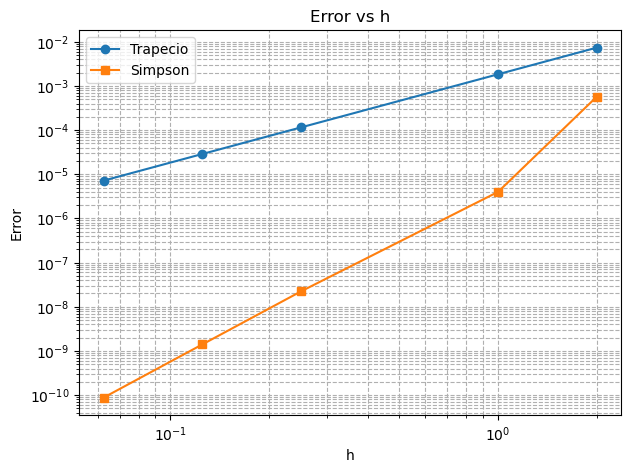

Valor exacto de la integral: 0.8813735870195429

Resultados:
n=  2 | h=2.00000 | error Trapecio=7.38e-03 | error Simpson=5.71e-04
n=  4 | h=1.00000 | error Trapecio=1.84e-03 | error Simpson=4.01e-06
n= 16 | h=0.25000 | error Trapecio=1.15e-04 | error Simpson=2.23e-08
n= 32 | h=0.12500 | error Trapecio=2.88e-05 | error Simpson=1.40e-09
n= 64 | h=0.06250 | error Trapecio=7.19e-06 | error Simpson=8.78e-11


In [23]:
import numpy as np
import matplotlib.pyplot as plt

#defino la integral
def f(x):
    return 1 / np.sqrt(x**2 + 16)

#limites de integracion
a = 0
b = 4

#calculo la integral exacta 

integral_exacta = np.log(4 + np.sqrt(4**2 + 16)) - np.log(0 + np.sqrt(0**2 + 16))

#primero el metodo del trapecio 

def trapecio_compuesto(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)
    I = h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])
    return I

#segundo el metodo de simpson

def simpson_compuesto(f, a, b, n):
    if n % 2 != 0:
        n += 1  # Simpson requiere número par de intervalos
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)
    I = (h/3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])
    return I

#calculo distintos n para el error

n_values = np.array([2, 4, 16, 32, 64])
h_values = (b - a) / n_values
error_trapecio = []
error_simpson = []

for n in n_values:
    I_trapecio = trapecio_compuesto(f, a, b, n)
    I_simpson = simpson_compuesto(f, a, b, n)
    error_trapecio.append(abs(integral_exacta - I_trapecio))
    error_simpson.append(abs(integral_exacta - I_simpson))

#grafico el error en funcion de h
                      
plt.figure(figsize=(7,5))
plt.loglog(h_values, error_trapecio, "o-", label="Trapecio")
plt.loglog(h_values, error_simpson, "s-", label="Simpson")
plt.xlabel("h")
plt.ylabel("Error")
plt.title("Error vs h")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

#resultados
print("Valor exacto de la integral:", integral_exacta)
print("\nResultados:")
for i in range(len(n_values)):
    print(f"n={n_values[i]:3d} | h={h_values[i]:.5f} | error Trapecio={error_trapecio[i]:.2e} | error Simpson={error_simpson[i]:.2e}")
